In [1]:
import numpy as np
from seaborn import kdeplot
import matplotlib.pyplot as plt
import os

plt.style.use("ggplot")

In [2]:
budget = 4 ** 8
conditioning_list = [4 ** i for i in range(9)]

wds_nn = np.zeros((10, len(conditioning_list)))
wds_mcmc = np.zeros((10, len(conditioning_list)))
wds_nn_std = np.zeros((10, len(conditioning_list)))
wds_mcmc_std = np.zeros((10, len(conditioning_list)))
for i in range(1,11):
    output_root = "budget_results"
    output_dir = os.path.join(output_root, f"ode_{i}")
    wd_nn_array = np.load(os.path.join(output_dir, "wd_nn_array_mean.npy"))
    wd_mcmc_array = np.load(os.path.join(output_root, f"wd_mcmc_array_mean_{i}.npy"))
    wd_nn_std = np.load(os.path.join(output_dir, "wd_nn_array_std.npy"))
    wd_mcmc_std = np.load(os.path.join(output_root, f"wd_mcmc_array_std_{i}.npy"))

    wds_nn[i-1, :] = wd_nn_array
    wds_mcmc[i-1, :] = wd_mcmc_array
    wds_nn_std[i-1, :] = wd_nn_std
    wds_mcmc_std[i-1, :] = wd_mcmc_std

In [3]:
wd_means = np.mean(wds_nn, axis=0)
wd_stds = np.mean(wds_nn_std, axis=0)

In [4]:
wd_mcmc_means = np.mean(wds_mcmc, axis=0)
wd_mcmc_stds = np.mean(wds_nn_std, axis=0)

In [6]:
wd_mcmc_means

array([0.89509756, 0.86183697, 0.83607742, 0.9410956 , 1.03051857,
       1.47009598, 2.44819665, 3.41786924, 3.67066714])

Text(0, 0.5, 'W2 Error')

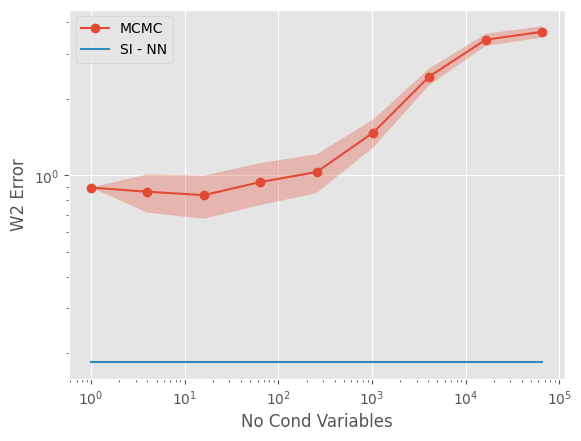

In [5]:
plt.plot(conditioning_list, wd_mcmc_means, label="MCMC", marker="o")
plt.fill_between(conditioning_list, wd_mcmc_means - wd_mcmc_stds, wd_mcmc_means + wd_mcmc_stds, alpha=0.3)
plt.plot(conditioning_list, np.mean(wd_means) * np.ones(9), label="SI - NN")
# plt.axhline(np.mean(wd_nn_array).item(), label="SI")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("No Cond Variables")
plt.ylabel("W2 Error")

In [14]:
wds_mcmc_1 = wds_mcmc[:, 0]
np.mean(wds_mcmc_1[wds_mcmc_1 <= 1.0])

np.float64(0.18904111856700004)

In [11]:
wds_nn.mean()

np.float64(0.18387813537841824)

In [15]:
mcmc_samps = np.load("mcmc_results/mcmc_results_5/mcmc_samps_65536_1.npy")
cond_var = np.load("mcmc_results/mcmc_results_5/cond_vars_1.npy")

In [19]:
rej_samps = np.load("rej_results/_5/rej_samps.npy")
cond_ys = np.load("rej_results/_5/conditioning_ys.npy")
rej_samp = rej_samps[np.where(cond_ys == cond_var), :]

In [22]:
rej_samp.squeeze()

array([-5.71944733,  6.66190379, -5.61609647, ...,  5.65734256,
        6.55473123,  6.39110947], shape=(1500,))

In [25]:
mcmc_samps.squeeze()

array([-0.75533431, -0.70768018, -4.69034925, ..., -5.67056087,
       -5.67056087, -5.67056087], shape=(65536,))

<Axes: ylabel='Density'>

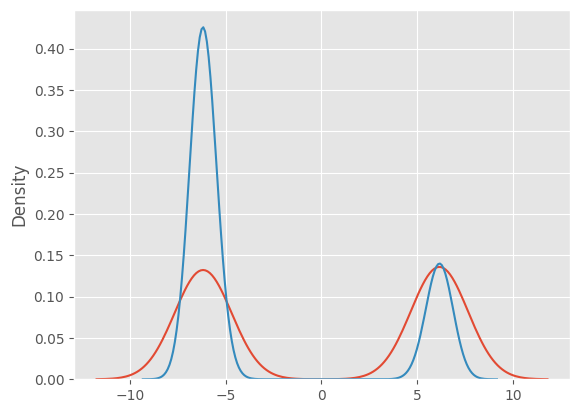

In [26]:
kdeplot(rej_samp.squeeze())
kdeplot(mcmc_samps.squeeze())

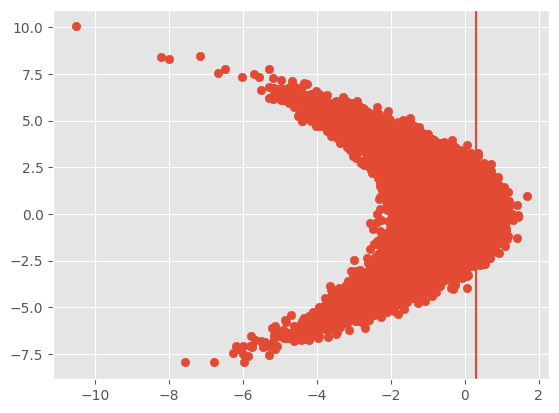

In [15]:
from triangular_transport.flows.methods.sampling import inf_train_gen
target_data = inf_train_gen(data="banana", rng=None, batch_size=budget)
plt.scatter(target_data[:, 0], target_data[:, 1])
plt.axvline(0.3)

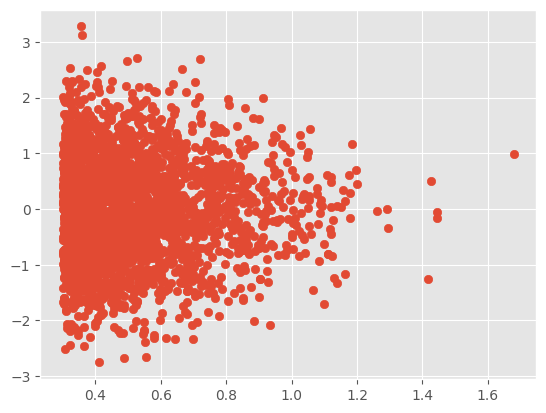

In [16]:
sub_data = target_data[np.where(target_data[:, 0] >= 0.3)[0]]
plt.scatter(sub_data[:, 0], sub_data[:, 1])

In [77]:
np.where(target_data[:, 0] >= 1.0)

(array([  200,  2304,  3889,  3964,  4859,  6934,  8541, 10894, 10989,
        11388, 11709, 13494, 15805, 16100, 16431, 17925, 18311, 19279,
        19826, 21210, 21255, 21778, 22481, 23786, 23842, 24328, 24884,
        25576, 26303, 26701, 30114, 30164, 30565, 31000, 31792, 32115,
        34320, 34836, 35196, 35322, 36159, 38090, 38249, 39510, 42396,
        43822, 46412, 46687, 46711, 46790, 47014, 48250, 48351, 49342,
        50649, 51254, 51893, 52166, 54206, 55660, 56929, 57522, 59152,
        60902, 61018, 62442, 62987, 63521]),)

In [76]:
np.max(target_data[:, 0])

np.float64(1.6780082795173554)

In [69]:
cond_vars[49]

np.float64(1.5765588923716285)

In [71]:
cond_vars[36]

np.float64(1.7298035568642156)